In [1]:
from pathlib import Path
import sys

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import get_project_root
print(get_project_root())
from pathlib import Path
from src.config import get_project_root


D:\MlOps_tasks\task_3


In [2]:
import pandas as pd, yaml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJ=get_project_root()
p=yaml.safe_load(open(PROJ/"config"/'params.yaml'))
ml_table = pd.read_csv(p['paths']['ml_train'])
print(ml_table.shape)
ml_table.head(2)

(67533, 97)


,order_purchase,order_estimated_delivery,num_sellers,num_items,total_price,total_freight_value,avg_seller_lat,avg_seller_lng,max_product_weight_grams,max_product_length_cm,...,cust_state_PR,cust_state_RJ,cust_state_RN,cust_state_RO,cust_state_RR,cust_state_RS,cust_state_SC,cust_state_SE,cust_state_SP,cust_state_TO
0,2016-09-15 12:16:38,2016-10-04,1.0,3.0,134.97,8.49,-25.507014,-49.275963,1000.0,16.0,...,0,0,0,0,0,0,0,0,1,0
1,2016-10-03 09:44:50,2016-10-27,1.0,1.0,29.90,15.56,-24.959184,-53.462644,300.0,16.0,...,0,0,0,0,0,0,0,0,1,0


In [3]:
#order_purchase,order_estimated_delivery,num_sellers,num_items,total_price,total_freight_value,
# avg_seller_lat,avg_seller_lng,max_product_weight_grams,max_product_length_cm,max_product_height_cm,
# max_product_width_cm,seller_zipcode,avg_product_name_length,avg_product_description_length,
# avg_product_photos_qty,sel_state_AC,sel_state_AM,sel_state_BA,sel_state_CE,sel_state_DF,sel_state_ES,
# sel_state_GO,sel_state_MA,sel_state_MG,sel_state_MS,sel_state_MT,sel_state_PA,sel_state_PB,sel_state_PE,
# sel_state_PI,sel_state_PR,sel_state_RJ,sel_state_RN,sel_state_RO,sel_state_RS,sel_state_SC,sel_state_SE,
# sel_state_SP,cat_automotivo,cat_bebes,cat_beleza_saude,cat_brinquedos,cat_cama_mesa_banho,
# cat_consoles_games,cat_cool_stuff,cat_eletronicos,cat_esporte_lazer,cat_fashion_bolsas_e_acessorios,
# cat_ferramentas_jardim,cat_informatica_acessorios,cat_moveis_decoracao,cat_moveis_escritorio,cat_other,
# cat_papelaria,cat_perfumaria,cat_pet_shop,cat_relogios_presentes,cat_telefonia,cat_utilidades_domesticas,
# num_payments,num_installments,total_payment_value,pay_boleto,pay_credit_card,pay_debit_card,pay_not_defined,
# pay_voucher,customer_zipcode,customer_lat,customer_lng,on_time,cust_state_AC,
# cust_state_AL,cust_state_AM,cust_state_AP,cust_state_BA,cust_state_CE,cust_state_DF,cust_state_ES,
# cust_state_GO,cust_state_MA,cust_state_MG,cust_state_MS,cust_state_MT,cust_state_PA,cust_state_PB,
# cust_state_PE,cust_state_PI,cust_state_PR,cust_state_RJ,cust_state_RN,cust_state_RO,cust_state_RR,
# cust_state_RS,cust_state_SC,cust_state_SE,cust_state_SP,cust_state_TO

######################################    data types  + shape (67533, 99) + memory 50 MB
ml_table['order_purchase']=pd.to_datetime(ml_table['order_purchase'])
ml_table['order_estimated_delivery']=pd.to_datetime(ml_table['order_estimated_delivery'])
ml_table['num_sellers']=ml_table['num_sellers'].astype('int32')
ml_table['num_items']=ml_table['num_items'].astype('int32')



print(ml_table.dtypes.head(60))
print(ml_table.dtypes.tail(30))
print(ml_table.shape)
print(ml_table.info())

order_purchase                     datetime64[us]
order_estimated_delivery           datetime64[us]
num_sellers                                 int32
num_items                                   int32
total_price                               float64
total_freight_value                       float64
avg_seller_lat                            float64
avg_seller_lng                            float64
max_product_weight_grams                  float64
max_product_length_cm                     float64
max_product_height_cm                     float64
max_product_width_cm                      float64
avg_product_name_length                   float64
avg_product_description_length            float64
avg_product_photos_qty                    float64
sel_state_AC                              float64
sel_state_AM                              float64
sel_state_BA                              float64
sel_state_CE                              float64
sel_state_DF                              float64


In [4]:
##############  Missing values: how many, where, and is the missing itself meaningful
print(ml_table[ml_table.columns[ml_table.isna().sum()>0]].isna().sum())


avg_seller_lat                     164
avg_seller_lng                     164
max_product_weight_grams            16
max_product_length_cm               16
max_product_height_cm               16
max_product_width_cm                16
avg_product_name_length           1197
avg_product_description_length    1197
avg_product_photos_qty            1197
num_payments                         1
num_installments                     1
total_payment_value                  1
pay_boleto                           1
pay_credit_card                      1
pay_debit_card                       1
pay_not_defined                      1
pay_voucher                          1
customer_lat                       181
customer_lng                       181
dtype: int64


In [5]:
######################  Numerical: statistics, distributions, skew, outliers, ranges that make no sense
print(ml_table.describe())


                   order_purchase    order_estimated_delivery   num_sellers  \
count                       67533                       67533  67533.000000   
mean   2017-10-20 23:51:27.394370  2017-11-14 14:11:33.101150      1.012053   
min           2016-09-15 12:16:38         2016-10-04 00:00:00      1.000000   
25%           2017-07-22 14:42:47         2017-08-15 00:00:00      1.000000   
50%           2017-11-18 22:53:19         2017-12-11 00:00:00      1.000000   
75%           2018-01-31 16:03:47         2018-03-01 00:00:00      1.000000   
max           2018-04-15 20:07:56         2018-08-03 00:00:00      5.000000   
std                           NaN                         NaN      0.114812   

          num_items   total_price  total_freight_value  avg_seller_lat  \
count  67533.000000  67533.000000         67533.000000    67369.000000   
mean       1.142079    135.884499            22.244256      -22.842637   
min        1.000000      2.290000             0.000000      -32.07

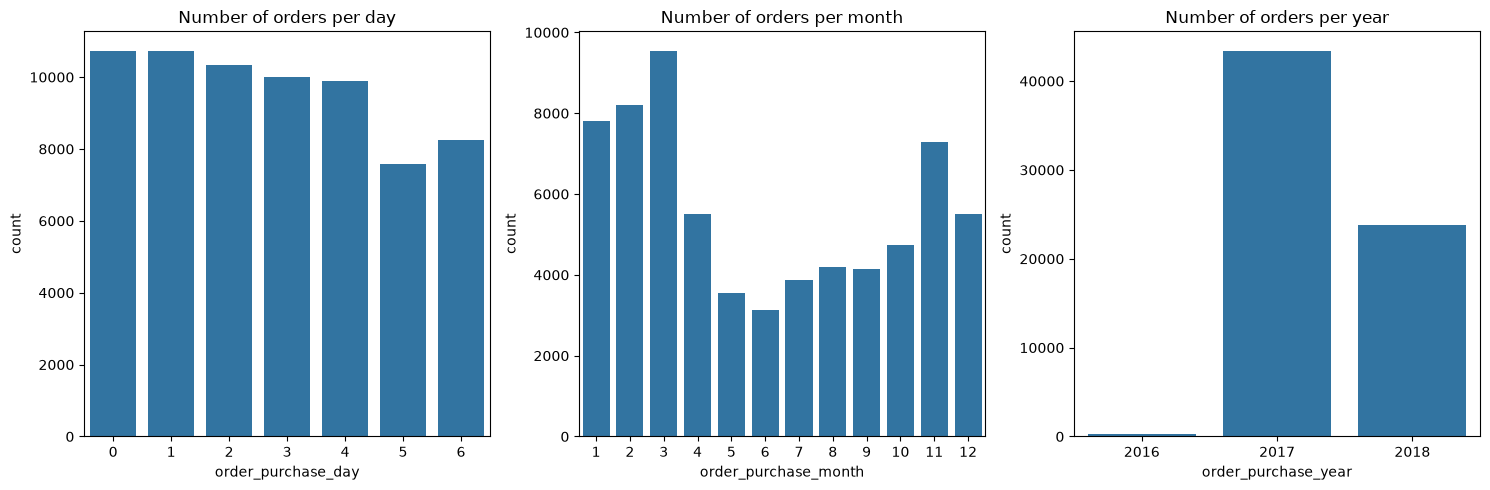

In [6]:
######################## I will return to this later, but for now, I know the features that I will make them
# for notebook5.
ml_table['order_purchase_month'] = ml_table['order_purchase'].dt.month
ml_table['order_purchase_year'] = ml_table['order_purchase'].dt.year
ml_table['order_purchase_day'] = ml_table['order_purchase'].dt.weekday



fig, ax = plt.subplots(1, 3, figsize=(15,5))

sns.countplot(x=ml_table['order_purchase_day'], ax=ax[0])
ax[0].set_title("Number of orders per day")

sns.countplot(x=ml_table['order_purchase_month'], ax=ax[1])
ax[1].set_title("Number of orders per month")

sns.countplot(x=ml_table['order_purchase_year'], ax=ax[2])
ax[2].set_title("Number of orders per year")

plt.tight_layout()
fig.savefig(p['paths']['artifacts_dist'], dpi=300, bbox_inches="tight")
plt.show()

27
Index(['cust_state_AC', 'cust_state_AL', 'cust_state_AM', 'cust_state_AP',
       'cust_state_BA', 'cust_state_CE', 'cust_state_DF', 'cust_state_ES',
       'cust_state_GO', 'cust_state_MA', 'cust_state_MG', 'cust_state_MS',
       'cust_state_MT', 'cust_state_PA', 'cust_state_PB', 'cust_state_PE',
       'cust_state_PI', 'cust_state_PR', 'cust_state_RJ', 'cust_state_RN',
       'cust_state_RO', 'cust_state_RR', 'cust_state_RS', 'cust_state_SC',
       'cust_state_SE', 'cust_state_SP', 'cust_state_TO'],
      dtype='str')
23
Index(['sel_state_AC', 'sel_state_AM', 'sel_state_BA', 'sel_state_CE',
       'sel_state_DF', 'sel_state_ES', 'sel_state_GO', 'sel_state_MA',
       'sel_state_MG', 'sel_state_MS', 'sel_state_MT', 'sel_state_PA',
       'sel_state_PB', 'sel_state_PE', 'sel_state_PI', 'sel_state_PR',
       'sel_state_RJ', 'sel_state_RN', 'sel_state_RO', 'sel_state_RS',
       'sel_state_SC', 'sel_state_SE', 'sel_state_SP'],
      dtype='str')


C:\Users\acer\AppData\Local\Temp\ipykernel_7668\4152142412.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ml_table.loc[index,'same_state']=0


same_state
0.0    46681
1.0    20852
Name: count, dtype: int64


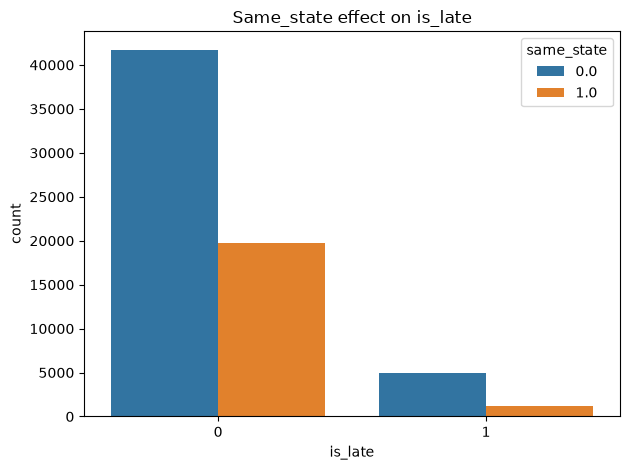

In [7]:
#customers and sellers from same state tend to be on_time or not

print(len(ml_table.columns[ml_table.columns.str.startswith('cust_state')]))
print(ml_table.columns[ml_table.columns.str.startswith('cust_state')])
print(len(ml_table.columns[ml_table.columns.str.startswith('sel_state')]))
print(ml_table.columns[ml_table.columns.str.startswith('sel_state')])

cust_states=[c for c in ml_table.columns[ml_table.columns.str.startswith('cust_state')]]
sel_states=[c for c in ml_table.columns[ml_table.columns.str.startswith('sel_state')]]

for index,row in ml_table.iterrows():
    for c_state in cust_states:
        if row[c_state] == 1:
            sel_state=[c for c in sel_states if c.endswith(c_state[-2:])]
            if len(sel_state)>0 and row[sel_state[0]]==1:
                ml_table.loc[index,'same_state']=1
            else:
                ml_table.loc[index,'same_state']=0

print(ml_table['same_state'].value_counts())

sns.countplot(data=ml_table,x='is_late',hue='same_state')
plt.title("Same_state effect on is_late")


plt.tight_layout()
plt.savefig(p['paths']['artifacts_state'], dpi=300, bbox_inches="tight")
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_7668\407907520.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ml_table['distance_km'] = haversine(ml_table['customer_lat'], ml_table['customer_lng'],


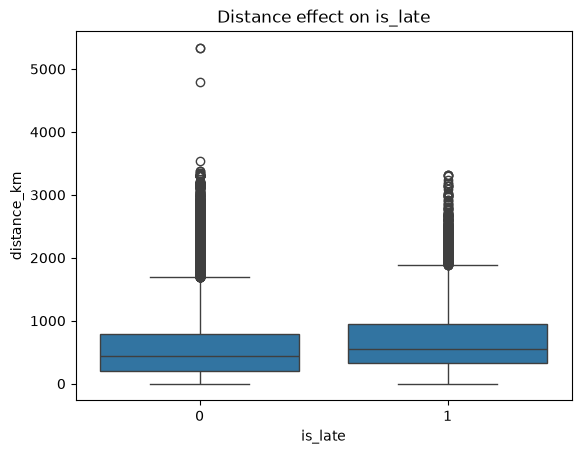

In [8]:
# distance between seller and customer Effect on on_time(the higher distance == the risk of (on_time=0) )
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


ml_table['distance_km'] = haversine(ml_table['customer_lat'], ml_table['customer_lng'],
                                   ml_table['avg_seller_lat'], ml_table['avg_seller_lng'])

sns.boxplot(
    data=ml_table,
    x='is_late',
    y='distance_km'
)

plt.title("Distance effect on is_late")
plt.savefig(p['paths']['artifacts_distance'], dpi=300, bbox_inches="tight")
plt.show()